In [80]:
import numpy as np
import pandas as pd

df = pd.read_parquet(
    "hf://datasets/somtoonkannebe/Nigeria-smoking-health/nigerian_smoking_health.parquet"
)

print(df.describe())

               age  cigs_per_day  hemoglobin_g_per_dL  heart_rate_bpm  \
count  3900.000000   3900.000000          3900.000000     3900.000000   
mean     36.369744      0.482821            12.812718       77.986667   
std      13.183212      2.729765             1.797341       14.518000   
min      18.000000      0.000000             6.000000       50.000000   
25%      25.000000      0.000000            11.800000       68.000000   
50%      34.000000      0.000000            12.900000       76.000000   
75%      46.000000      0.000000            14.000000       86.000000   
max      70.000000     40.000000            18.000000      140.000000   

       cholesterol_mg_per_dL  
count            3900.000000  
mean              218.827769  
std                36.139316  
min               120.000000  
25%               193.800000  
50%               217.800000  
75%               242.825000  
max               380.200000  


In [81]:
df.head()

,age,sex,region,location_type,current_smoker,cigs_per_day,sickle_cell_genotype,malaria_exposure,hemoglobin_g_per_dL,heart_rate_bpm,blood_pressure,cholesterol_mg_per_dL
0,22,male,South_West,urban,no,0,AA,chronic,14.5,70,119/60,254.3
1,22,female,North_West,urban,no,0,AA,rare,14.5,69,141/91,217.8
2,53,female,North_East,rural,no,0,AS,rare,13.9,79,122/62,197.4
3,40,male,North_West,rural,no,0,AS,rare,14.4,67,122/81,197.5
4,29,male,South_East,rural,no,0,AA,rare,14.8,52,107/61,155.8


In [82]:
df.isna().sum()

age                      0
sex                      0
region                   0
location_type            0
current_smoker           0
cigs_per_day             0
sickle_cell_genotype     0
malaria_exposure         0
hemoglobin_g_per_dL      0
heart_rate_bpm           0
blood_pressure           0
cholesterol_mg_per_dL    0
dtype: int64

In [84]:
df.drop(columns=["current_smoker"], inplace=True)
df["sex"] = df["sex"].transform(lambda x: 1 if x == "male" else 0)
df["blood_pressure_upper"] = df["blood_pressure"].str.split("/").str[0].astype(float)
df["blood_pressure_lower"] = df["blood_pressure"].str.split("/").str[1].astype(float)
df.drop(columns=["blood_pressure"], inplace=True)
df.drop(columns=["location_type", "region"], inplace=True)
malaria_exposure_mapping = {"rare": 0, "recent": 0.5, "chronic": 1}


df["malaria_exposure"] = df["malaria_exposure"].map(malaria_exposure_mapping)

In [85]:
df.dtypes

age                        int64
sex                        int64
cigs_per_day               int64
sickle_cell_genotype         str
malaria_exposure         float64
hemoglobin_g_per_dL      float64
heart_rate_bpm             int64
cholesterol_mg_per_dL    float64
blood_pressure_upper     float64
blood_pressure_lower     float64
dtype: object

In [86]:
df["cardio_risk"] = (
    (df["blood_pressure_upper"] >= 140)
    | (df["blood_pressure_lower"] >= 90)
    | (df["cholesterol_mg_per_dL"] >= 240)
    | (df["heart_rate_bpm"] > 100)
).astype(int)

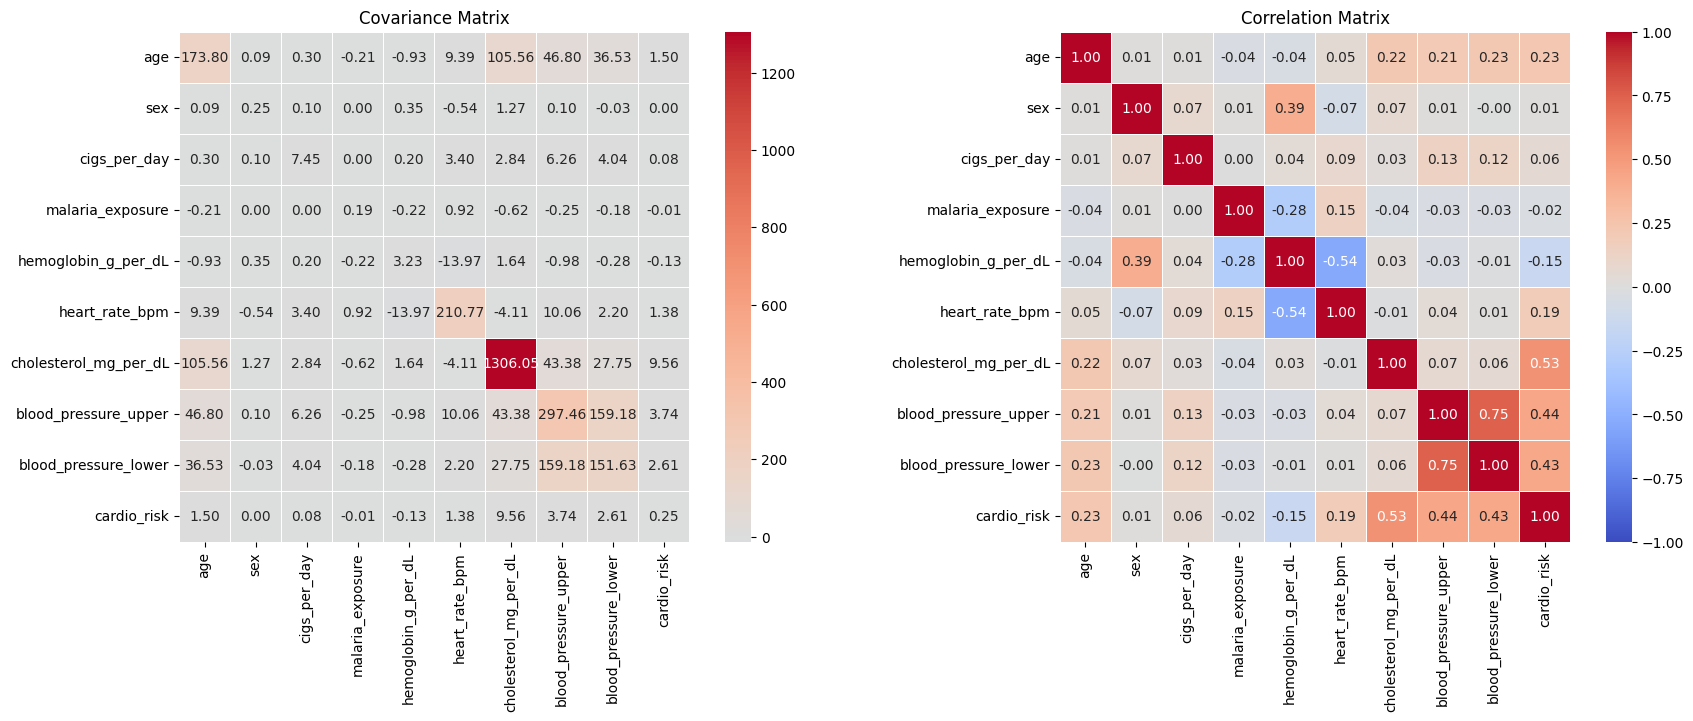

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=[np.number])
covariance_matrix = numeric_df.cov()
correlation_matrix = numeric_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    covariance_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Covariance Matrix")

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [56]:
cat_cols = ["sickle_cell_genotype"]

num_cols = [col for col in df.columns if col not in cat_cols + ["cardio_risk"]]

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

In [65]:
df.to_csv("nigerian_smoking_health.csv", index=False)

In [88]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df.drop(columns=["cardio_risk"])
y = df["cardio_risk"]

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]


X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

array([[-0.34534069,  1.01030955, -0.1851253 , ...,  1.        ,
         0.        ,  0.        ],
       [-0.42087262, -0.98979565, -0.1851253 , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.56104245, -0.98979565, -0.1851253 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 2.37380873, -0.98979565, -0.1851253 , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.40997859, -0.98979565, -0.1851253 , ...,  1.        ,
         0.        ,  0.        ],
       [-0.6474684 , -0.98979565, -0.1851253 , ...,  0.        ,
         0.        ,  1.        ]], shape=(3120, 12))